## Post downloader

Description about each cell is in the **imdb_reviews_scraper.ipynb** file

In [3]:
import pandas as pd
import string
import json
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
import csv
import gzip
import json
import ssl
import sys
import time
import urllib.error
import urllib.parse
import urllib.request

In [ ]:
GRAPHQL_URL = "https://caching.graphql.imdb.com/"
SUGGESTION_URL = "https://v3.sg.media-imdb.com/suggestion/x/{}.json"

# O Python do python.org no macOS nao usa o keychain do sistema: sem isto todo
# urlopen morre com CERTIFICATE_VERIFY_FAILED. O certifi resolve na hora.
try:
    import certifi

    CA_BUNDLE = certifi.where()
    SSL_CONTEXT = ssl.create_default_context(cafile=CA_BUNDLE)
except ModuleNotFoundError:
    CA_BUNDLE = "padrao do sistema (certifi nao instalado)"
    SSL_CONTEXT = ssl.create_default_context()

CERT_HELP = (
    "Falha ao validar o certificado SSL do IMDb. Duas saidas:\n"
    "  1) instale o certifi e rode esta celula de novo:  %pip install certifi\n"
    "  2) ou rode uma vez o instalador de certificados do seu Python:\n"
    "     open '/Applications/Python 3.10/Install Certificates.command'"
)

# Conjunto minimo, verificado por teste (3 rodadas por caso, com ids de filme
# diferentes para nao pegar cache do endpoint):
#   Content-Type       -> obrigatorio: sem ele o GraphQL responde 415
#   Referer do imdb.com-> sozinho ja libera (de outro dominio da 403)
#   x-imdb-client-name -> sozinho tambem libera; o valor nao e validado
# Os dois ultimos sao redundantes entre si: qualquer um basta. Mantidos ambos
# de proposito, para o caso de o IMDb apertar um dos caminhos.
# Removidos por serem inertes: User-Agent, Origin, Accept, Accept-Language
# (UA de navegador sozinho da 403; UA de curl + client-name da 200).
HEADERS = {
    "Content-Type": "application/json",
    "Referer": "https://www.imdb.com/",
    "x-imdb-client-name": "imdb-web-next",
    "Accept-Encoding": "gzip",  # se a resposta vier comprimida, _http_json descomprime
}


def _http_json(url, payload=None, retries=5):
    """GET (payload=None) ou POST JSON, com retry e backoff exponencial."""
    data = json.dumps(payload).encode("utf-8") if payload is not None else None

    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, data=data, headers=HEADERS)
            with urllib.request.urlopen(req, timeout=30, context=SSL_CONTEXT) as resp:
                raw = resp.read()
                if resp.headers.get("Content-Encoding") == "gzip":
                    raw = gzip.decompress(raw)
                return json.loads(raw.decode("utf-8"))

        except urllib.error.HTTPError as exc:
            # 4xx que nao seja rate-limit nao melhora com retry
            if exc.code not in (429, 500, 502, 503, 504) or attempt == retries - 1:
                raise
        except (urllib.error.URLError, TimeoutError) as exc:
            # certificado quebrado tambem nao melhora com retry: falha na hora
            if isinstance(getattr(exc, "reason", None), ssl.SSLCertVerificationError):
                raise RuntimeError(CERT_HELP) from exc
            if attempt == retries - 1:
                raise

        wait = 2 ** attempt
        print(f"  ! tentativa {attempt + 1}/{retries} falhou; aguardando {wait}s")
        time.sleep(wait)


print(f"helpers carregados | Python {'.'.join(map(str, sys.version_info[:3]))}")
print(f"certificados: {CA_BUNDLE}")

helpers carregados | Python 3.14.5
certificados: c:\Users\Daniel\Desktop\Códigos\NPL-sentiment-analyzer\venv\Lib\site-packages\certifi\cacert.pem


In [6]:
# Filme alvo: informe o NOME (a busca resolve o ID) ou o IMDB_ID direto.
MOVIE_TITLE = "Supergirl"
IMDB_ID = "tt8814476"  # ex: "tt22084616" — se preenchido, ignora MOVIE_TITLE

# Quantos reviews baixar
N_REVIEWS = 500

# Ordenacao: HELPFULNESS_SCORE | SUBMISSION_DATE | USER_RATING
#            | TOTAL_VOTES | SUBMITTER_REVIEW_COUNT
SORT_BY = "HELPFULNESS_SCORE"
SORT_ORDER = "DESC"  # DESC ou ASC

# Educacao / boa vizinhanca: pausa entre requisicoes (segundos)
DELAY = 0.5

# Prefixo dos arquivos de saida (.csv e .json)
OUTPUT_PREFIX = None  # None = gera automaticamente a partir do ID

In [5]:
def search_titles(query, limit=6):
    """Lista os candidatos do IMDb para um nome, em ordem de relevancia."""
    payload = _http_json(SUGGESTION_URL.format(urllib.parse.quote(query)))
    return [
        {"id": it["id"], "name": it.get("l"), "type": it.get("q"), "year": it.get("y")}
        for it in payload.get("d", [])
        # entradas editoriais (listas, artigos) nao tem id comecando com "tt"
        if str(it.get("id", "")).startswith("tt")
    ][:limit]


def find_title_id(query, limit=6):
    """Resolve nome -> (id, titulo, ano), mostrando os demais candidatos.

    A busca do IMDb rankeia por popularidade atual, nao por match exato:
    "Dune" devolve Dune: Part Two (2024) e "Avatar" devolve Avatar Aang (2026),
    nao os filmes que voce provavelmente quer. Por isso os outros candidatos
    aparecem — se o escolhido estiver errado, copie o ID certo para IMDB_ID.
    """
    candidatos = search_titles(query, limit)
    if not candidatos:
        raise ValueError(f"nenhum titulo encontrado para {query!r}")

    escolhido, *outros = candidatos
    print(f"'{query}' -> {escolhido['id']} | {escolhido['name']} "
          f"({escolhido['year']}) [{escolhido['type']}]")

    if outros:
        print("\n  outros candidatos — se o de cima estiver errado, cole o ID em IMDB_ID:")
        for c in outros:
            print(f"    {c['id']}  {c['name']} ({c['year']}) [{c['type']}]")

    return escolhido["id"], escolhido["name"], escolhido["year"]


if IMDB_ID:
    title_id = IMDB_ID
    print(f"usando ID fixo: {title_id}")
else:
    title_id, resolved_name, resolved_year = find_title_id(MOVIE_TITLE)

usando ID fixo: tt8814476


In [7]:
PAGE_SIZE = 50  # maximo aceito pelo endpoint

REVIEWS_QUERY = """
query TitleReviews($id: ID!, $first: Int!, $after: ID, $sort: ReviewsSortBy!, $order: SortOrder!) {
  title(id: $id) {
    titleText { text }
    releaseYear { year }
    ratingsSummary { aggregateRating voteCount }
    reviews(first: $first, after: $after, sort: { by: $sort, order: $order }) {
      total
      pageInfo { hasNextPage endCursor }
      edges {
        node {
          id
          summary { originalText }
          text { originalText { plainText } }
          authorRating
          submissionDate
          spoiler
          helpfulness { upVotes downVotes }
          author { nickName userId }
        }
      }
    }
  }
}
"""

print("query definida")

query definida


In [8]:
def sentiment_from_rating(rating):
    """Rotulo derivado da nota do autor (1-10), para usar como label de treino."""
    if rating is None:
        return "unknown"
    if rating <= 4:
        return "negative"
    if rating <= 6:
        return "neutral"
    return "positive"


def fetch_reviews(title_id, limit, sort=SORT_BY, order=SORT_ORDER, delay=DELAY):
    reviews, seen, cursor, meta, page = [], set(), None, {}, 0

    while len(reviews) < limit:
        page += 1
        variables = {
            "id": title_id,
            "first": min(PAGE_SIZE, limit - len(reviews)),
            "sort": sort,
            "order": order,
        }
        if cursor:
            variables["after"] = cursor

        payload = _http_json(GRAPHQL_URL, {"query": REVIEWS_QUERY, "variables": variables})

        if "errors" in payload:
            raise RuntimeError(json.dumps(payload["errors"], indent=2))

        title = (payload.get("data") or {}).get("title")
        if not title:
            raise RuntimeError(f"titulo {title_id} nao encontrado")

        block = title["reviews"]

        if not meta:
            meta = {
                "imdb_id": title_id,
                "title": title["titleText"]["text"],
                "year": (title.get("releaseYear") or {}).get("year"),
                "imdb_rating": (title.get("ratingsSummary") or {}).get("aggregateRating"),
                "imdb_votes": (title.get("ratingsSummary") or {}).get("voteCount"),
                "reviews_available": block["total"],
            }
            print(f"{meta['title']} ({meta['year']}) — nota {meta['imdb_rating']} — "
                  f"{meta['reviews_available']} reviews disponiveis\n")

        for edge in block["edges"]:
            node = edge["node"]
            if node["id"] in seen:
                continue
            seen.add(node["id"])

            rating = node.get("authorRating")
            reviews.append({
                "review_id": node["id"],
                "title": (node.get("summary") or {}).get("originalText") or "",
                "review": ((node.get("text") or {}).get("originalText") or {}).get("plainText") or "",
                "rating": rating,
                "sentiment": sentiment_from_rating(rating),
                "date": node.get("submissionDate"),
                "author": (node.get("author") or {}).get("nickName"),
                "author_id": (node.get("author") or {}).get("userId"),
                "spoiler": node.get("spoiler"),
                "helpful_up": (node.get("helpfulness") or {}).get("upVotes"),
                "helpful_down": (node.get("helpfulness") or {}).get("downVotes"),
                "url": f"https://www.imdb.com/review/{node['id']}/",
            })

        pct = 100 * len(reviews) / limit
        print(f"\rpagina {page:>3} | {len(reviews):>5}/{limit} reviews ({pct:5.1f}%)", end="")

        if not block["pageInfo"]["hasNextPage"]:
            print("\n\nacabaram os reviews disponiveis antes de atingir a meta")
            break

        cursor = block["pageInfo"]["endCursor"]
        time.sleep(delay)

    print(f"\n\nconcluido: {len(reviews)} reviews")
    return reviews[:limit], meta


print("funcao pronta")

funcao pronta


In [9]:
reviews, meta = fetch_reviews(title_id, N_REVIEWS)

Supergirl (2026) — nota 5.9 — 1853 reviews disponiveis

pagina  10 |   500/500 reviews (100.0%)

concluido: 500 reviews


In [10]:
df = pd.DataFrame(reviews)
df["date"] = pd.to_datetime(df["date"])
df["rating"] = pd.to_numeric(df["rating"])
df["n_chars"] = df["review"].str.len()
df["n_words"] = df["review"].str.split().str.len()

print(f"shape: {df.shape}")
df.head()

shape: (500, 14)


,review_id,title,review,rating,sentiment,date,author,author_id,spoiler,helpful_up,helpful_down,url,n_chars,n_words
0,rw11594246,supergirl can't save this weak script.,I went into this movie excited to watch Superg...,5.0,neutral,2026-06-24,hyde_20,ur23571721,False,890,293,https://www.imdb.com/review/rw11594246/,1478,248
1,rw11596245,Why,They poisoned the dog. Except instead of John ...,5.0,neutral,2026-06-25,syedhaye,ur128755800,True,508,231,https://www.imdb.com/review/rw11596245/,2063,344
2,rw11606552,It was a let down,"I had high expectations for Supergirl (2026), ...",6.0,neutral,2026-06-28,EnriqueE-14,ur220950445,False,146,82,https://www.imdb.com/review/rw11606552/,1447,248
3,rw11611931,"Weak Script, CGI dog distracting","I am not a DC Universe nerd, although two of t...",NaN,unknown,2026-06-30,derricsaville,ur64216059,True,128,66,https://www.imdb.com/review/rw11611931/,2781,503
4,rw11596945,"An Ordinary Villain, An Ordinary Movie",I wasn't disappointed because I didn't have hi...,6.0,neutral,2026-06-25,AdnanAlzahrani,ur21270510,False,203,125,https://www.imdb.com/review/rw11596945/,367,57


In [11]:
print(f"linhas ................ {len(df)}")
print(f"review_ids unicos ..... {df['review_id'].nunique()}")
print(f"textos vazios ......... {(df['review'].str.strip() == '').sum()}")
print(f"sem nota do autor ..... {df['rating'].isna().sum()}")
print(f"periodo ............... {df['date'].min():%Y-%m-%d} a {df['date'].max():%Y-%m-%d}")
print(f"tamanho medio ......... {df['n_words'].mean():.0f} palavras "
      f"(mediana {df['n_words'].median():.0f})")
print(f"nota media do autor ... {df['rating'].mean():.2f}")

print("\ndistribuicao de sentimento:")
dist = df["sentiment"].value_counts()
for label, count in dist.items():
    bar = "#" * round(50 * count / len(df))
    print(f"  {label:<9} {count:>5} ({100 * count / len(df):4.1f}%) {bar}")

print("\ndistribuicao de notas:")
for rating, count in df["rating"].value_counts().sort_index().items():
    bar = "#" * round(50 * count / len(df))
    print(f"  {int(rating):>2}/10 {count:>5} {bar}")

linhas ................ 500
review_ids unicos ..... 500
textos vazios ......... 0
sem nota do autor ..... 15
periodo ............... 2026-06-24 a 2026-08-15
tamanho medio ......... 205 palavras (mediana 126)
nota media do autor ... 5.08

distribuicao de sentimento:
  positive    226 (45.2%) #######################
  negative    172 (34.4%) #################
  neutral      87 (17.4%) #########
  unknown      15 ( 3.0%) ##

distribuicao de notas:
   1/10   104 ##########
   2/10    20 ##
   3/10    30 ###
   4/10    18 ##
   5/10    18 ##
   6/10    69 #######
   7/10   177 ##################
   8/10    33 ###
   9/10    10 #
  10/10     6 #


In [8]:
prefix = OUTPUT_PREFIX or f"../results/{MOVIE_TITLE}/imdb_{title_id}_reviews"

df.drop(columns=["n_chars", "n_words"]).to_csv(
    f"{prefix}.csv", index=False, quoting=csv.QUOTE_ALL, encoding="utf-8"
)

with open(f"{prefix}.json", "w", encoding="utf-8") as fh:
    json.dump({"meta": meta, "count": len(reviews), "reviews": reviews},
              fh, ensure_ascii=False, indent=2)

print(f"salvo: {prefix}.csv")
print(f"salvo: {prefix}.json")

salvo: ../results/Supergirl/imdb_tt8814476_reviews.csv
salvo: ../results/Supergirl/imdb_tt8814476_reviews.json


# Post sentiment analyzer

The code commented below is an alternative method of findind words that isnt found in the **anew.csv** due to the difference of characters, but have the same meaning, using the similarity between words, like:

- annoy/annoyed - 76% similarity
- frustrated/frustrating - 74% similarity

It takes too much time because it needs to use an *for* to calculate the similarity of each word in the **anew.csv** and in the text.


In [ ]:
# anew_w = pd.read_csv("../anew/anew.csv")
# anew_w = anew_w.drop(columns=["arousal", "dominance"])

# def similar_string(string):
#     similar = ["", "", 0]
#     for term in anew_w["term"].values:
#         similarity = SequenceMatcher(None, string, term).ratio()

#         if similarity > 0.7 and similarity > similar[2]:
#             similar = [term, string, similarity]
#             # print(similar)
    
#     return similar[0]

# def post_analyzer(text=str):
#     new_text = text.translate(
#         str.maketrans("", "", string.punctuation)
#     )
#     new_text = new_text.lower().split()

#     positive_w = []
#     p_sum = 0

#     negative_w = []
#     n_sum = 0

#     neutral_w = []

#     positive_score = 0
#     negative_score = 0

#     for word in new_text:
#         if not word in anew_w["term"].values:
#             word = similar_string(word)

#         if word and word in anew_w["term"].values:
#             element = anew_w[anew_w["term"] == word]
#             pleasure = element["pleasure"].iloc[0]

#             score = (pleasure - 50) / 50 * 10

#             if score > 0:
#                 p_sum += score
#                 positive_w.append((word, score))

#             elif score < 0:
#                 n_sum += score
#                 negative_w.append((word, score))

#             else:
#                 neutral_w.append((word, score))

#     # result = p_sum - (-n_sum)

#     if len(positive_w) > 0:
#         positive_score = p_sum / (len(positive_w) * 10)

#     if len(negative_w) > 0:
#         negative_score = -n_sum / (len(negative_w) * 10)

#     result = positive_score - negative_score

#     # print("Positive:", positive_w)
#     # print("Negative:", negative_w)
#     # print("Neutral:", neutral_w)

#     if result > 0:
#         return "Positive post"

#     elif result < 0:
#         return "Negative post"

#     return "Neutral post"

The code below uses the ANEW dataset to find words and their emotional scores and each word receives a score from negative to positive.

- Removes punctuation and converts the text to lowercase
- Checks which words exist in the ANEW dataset
- Separates words into positive and negative
- Detects negation words, such as "not" and "never", and reverses the word's sentiment
- Calculates an overall sentiment score for the text
- Returns "Positive post" if the score is positive and "Negative post" otherwise
- Returns "Unknown" in a specific case where there are many positive words but no negative words

The reason of the Unknown is because there is situations where the function cant find any word Negative but finds a lot of Positive, or any Positives but a lot of Negatives, an example would be the review of the post *rw11594246* from the Supergirl movie, the review have some words like *frustrating* and *annoying*, that in the anew.csv, is *frustrated* and *annoy*, because of this, the function cant find properly the words in the anew.csv and make *false positives* and *false negatives*

In [ ]:
anew_w = pd.read_csv("../anew/anew.csv")
anew_w = anew_w.drop(columns=["arousal", "dominance"])

negators = {
    "not", "no", "never", "nothing", "none", "neither", "nor", "cannot", "cant",
    "dont", "doesnt", "didnt", "wasnt", "werent", "isnt", "arent", "wont",
    "wouldnt", "couldnt", "shouldnt", "without", "hardly", "barely", "rarely",
}

def post_analyzer(text=str):
    new_text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    new_text = new_text.lower().split()

    positive_w = []
    p_sum = 0

    negative_w = []
    n_sum = 0

    positive_score = 0
    negative_score = 0
    
    for i in range(len(new_text)):
        word = new_text[i]
        negated = False

        if word and word in anew_w["term"].values:
            element = anew_w[anew_w["term"] == word]
            pleasure = element["pleasure"].iloc[0]

            score = (pleasure - 50) / 50 * 10

            if i > 0 and i < len(new_text) - 1:
                if new_text[i + 1] in negators or new_text[i - 1] in negators:
                    negated = True

            if not negated:
                if score > 0:
                    p_sum += score
                    positive_w.append((word, score))

                elif score < 0:
                    n_sum += score
                    negative_w.append((word, score))

            else:
                if score < 0:
                    p_sum += score
                    positive_w.append(("!" + word, score))

                elif score > 0:
                    n_sum += score
                    negative_w.append(("!" + word, score))

    # result = p_sum - (-n_sum)

    if len(positive_w) > 0:
        positive_score = p_sum / len(positive_w)

    if len(negative_w) > 0:
        negative_score = -n_sum / len(negative_w)

    result = positive_score - negative_score

    # print("Positive:", positive_w)
    # print("Negative:", negative_w)

    if len(positive_w) > 10 and len(negative_w) == 0:
        return "Unknown"

    if result > 0:
        return "Positive post"

    return "Negative post"

In [6]:
text = '''
"I went into this movie excited to watch Supergirl, but somehow the film seemed far more interested in another character that was constantly pushed to the forefront. By the end, it felt like she was the actual protagonist while Supergirl had been reduced to a supporting role in her own movie.\n\nThis character is easily the most frustrating part of the film. Her dialogue is annoying, her performance never clicked with me, and the camera keeps returning to her so often that it becomes distracting. What's worse is that she doesn't have any meaningful character arc that justifies the amount of screen time she receives.\n\nThe screenplay is shockingly weak. Considering the budget and the talent involved, this should have been a far more entertaining and engaging film. Instead, it somehow manages to be dull, poorly paced, and emotionally flat. It's genuinely surprising that a movie with so many resources ended up feeling this underdeveloped.\n\nAs for Supergirl herself, she's actually one of the few bright spots. She has charisma, presence, and looks every bit the hero the movie should have focused on.\n\nUnfortunately, the lack of chemistry between the two leads drags the entire film down, and she simply isn't given enough material to carry the story by herself.\n\nThis is one of the most disappointing superhero movies I've seen in recent years. A strong lead performance can't save a film when the script is this weak and the focus is placed on all the wrong characters.",

'''

print(post_analyzer(text))

Positive post


In [ ]:
analyze_result = {}

# prefix = f"../results/{"hannah montana"}/imdb_{"tt1114677"}_reviews"

with open(prefix + ".json", "r", encoding="utf-8") as post_file:
    posts = json.load(post_file)

for post in posts["reviews"]:
    analyze_result[post["review_id"]] = post_analyzer(post["review"])

print(analyze_result)


{'rw2055940': 'Positive post', 'rw3026375': 'Positive post', 'rw2113716': 'Positive post', 'rw2052155': 'Unknown', 'rw2211211': 'Positive post', 'rw2050410': 'Positive post', 'rw10098464': 'Unknown', 'rw2055231': 'Positive post', 'rw6241825': 'Positive post', 'rw2078904': 'Unknown', 'rw4770166': 'Positive post', 'rw3660369': 'Unknown', 'rw6762593': 'Unknown', 'rw2054117': 'Positive post', 'rw2052800': 'Positive post', 'rw2053289': 'Positive post', 'rw2178765': 'Unknown', 'rw2055454': 'Positive post', 'rw2689402': 'Positive post', 'rw2196889': 'Positive post', 'rw2050897': 'Positive post', 'rw2060795': 'Unknown', 'rw2057014': 'Positive post', 'rw2107111': 'Positive post', 'rw2341723': 'Positive post', 'rw2269897': 'Positive post', 'rw2051968': 'Positive post', 'rw2768504': 'Positive post', 'rw6559952': 'Positive post', 'rw2129619': 'Positive post', 'rw6862246': 'Negative post', 'rw2448730': 'Positive post', 'rw2184052': 'Positive post', 'rw5717012': 'Negative post', 'rw2287015': 'Positi

In [19]:
positive = 0
negative = 0
unknown = 0

for result in analyze_result:
    if analyze_result[result] == "Positive post":
        positive += 1

    elif analyze_result[result] == "Negative post":
        negative += 1

    else:
        unknown += 1

positive_per = positive/(positive + negative + unknown) * 100
negative_per = negative/(positive + negative + unknown) * 100
unknown_per = unknown/(positive + negative + unknown) * 100

print(f"Positive posts: {positive_per:.2f}%")
print(f"Negative posts: {negative_per:.2f}%")
print(f"Unknown posts: {unknown_per:.2f}%")

Positive posts: 71.04%
Negative posts: 2.73%
Unknown posts: 26.23%


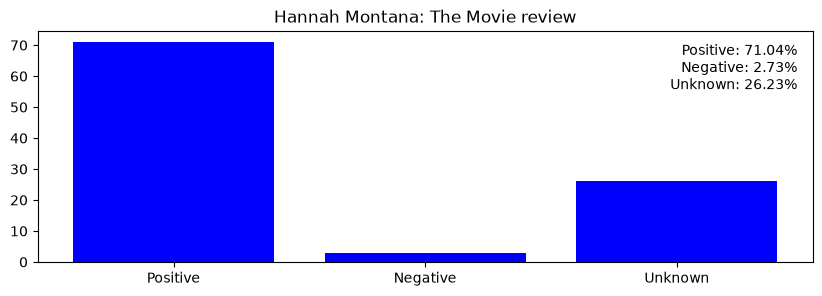

In [20]:
sentiments = ["Positive", "Negative", "Unknown"]
percentages = [positive_per, negative_per, unknown_per]

plt.figure(figsize=(10,3))
plt.bar(sentiments, percentages, color='blue', linewidth=1.3)

plt.text(
    0.98, 0.95,
    f"Positive: {positive_per:.2f}%\nNegative: {negative_per:.2f}%\nUnknown: {unknown_per:.2f}%",
    transform=plt.gca().transAxes,
    ha="right",
    va="top"
)
plt.title(f"{posts["meta"]["title"]} review")
plt.show()